# ENVRI-Hub NEXT

## Access EXV related ACTRIS (meta)data

## Install missing packages
Install the following packages, if you have not already installed them in your environment:
* pip install SPARQLWrapper

If needed, uncomment and run the next cell. 
Then, restart the Kernel. 

In [1]:
# pip install SPARQLWrapper

## Import Libraries
Import the required libraries

In [2]:
# Library for working with netCDF files
import xarray as xr

# Libraries for working with JSON files, making HTTP requests, and handling file system operations
import json
import requests
import os

# Library for plotting data
import matplotlib.pyplot as plt

# Library for querying SPARQL endpoints
from SPARQLWrapper import SPARQLWrapper, JSON

## Get EXV-related ACTRIS observed properties
Use a SPARQL query to get the list of observed properties related to a specific EXV from the ACTRIS Vocabulary. 

In [3]:
def EXV_iadopt():
    # SPARQL endpoint
    endpoint_url = "https://vocabulary.actris.nilu.no/fuseki/skosmos/sparql"

    # Construct full identifier
    # exv_identifier = f"SDN:EXV::{exv_code}"

    # Create the query with the user input
    query = f"""
prefix skos: <http://www.w3.org/2004/02/skos/core#>
prefix iop: <https://w3id.org/iadopt/ont/>
prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#>
prefix owl: <http://www.w3.org/2002/07/owl#>
prefix xsd: <http://www.w3.org/2001/XMLSchema#>
prefix ACTRIS_vocab: <https://vocabulary.actris.nilu.no/actris_vocab/>

SELECT DISTINCT ?aerosol_variable_ParticlePhase
#?aerosol_variable_ParticlePhase
from <https://vocabulary.actris.nilu.no/actris_vocab/>
WHERE {{ 
    #ACTRIS_vocab:aerosolvariables skos:narrower ?aerosol_variable_url.
    #?aerosol_variable_url iop:hasObjectOfInterest ACTRIS_vocab:particlephase.
      ?aerosol_variable_url iop:hasMatrix ACTRIS_vocab:aerosolparticlephase;
			skos:prefLabel ?aerosol_variable_ParticlePhase
	}}
"""

    # Set up the SPARQL request
    sparql = SPARQLWrapper(endpoint_url)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)

    # Run the query and parse results
    results = sparql.query().convert()

    observed_properties = []

    # Show results
    for result in results["results"]["bindings"]:
        uri = result.get("aerosol_variable_ParticlePhase", {}).get("value", "")
        observed_properties.append(uri)
    
    return observed_properties

aerosol_variables = EXV_iadopt()
print(aerosol_variables)
print("\nNumber of EXV-related variables: " + str(len(aerosol_variables)))


['aerosol particle aluminium mass concentration', 'aerosol particle ammonium mass concentration', 'aerosol particle arsenic mass concentration', 'aerosol particle backscatter coefficient', 'aerosol particle barium mass concentration', 'aerosol particle bromine mass concentration', 'aerosol particle cadmium mass concentration', 'aerosol particle calcium mass concentration', 'aerosol particle carbonate carbon mass concentration', 'aerosol particle carbon mass concentration', 'aerosol particle chloride mass concentration', 'aerosol particle chlorine mass concentration', 'aerosol particle chromium mass concentration', 'aerosol particle cobalt mass concentration', 'aerosol particle copper mass concentration', 'aerosol particle effective radius', 'aerosol particle elemental carbon mass concentration', 'aerosol particle equivalent black carbon mass concentration', 'aerosol particle iron mass concentration', 'aerosol particle lead mass concentration', 'aerosol particle light absorption coeffic

## Collect metadata
Harvest metadata cointaining the observed properties via the ACTRIS Metadata Catalogue API. 

### Define the search filters
Set the search parameters in the following cell.

In [6]:
# Start time = time_period_begin
start_time = '2023-02-01T00:00:00'
# End time = time_period_end
end_time = '2023-02-28T23:59:59'
# Variable name = attribute_descriptions
variable_list = ""
for variable in aerosol_variables: 
    variable_list += "\"" +  variable + "\","
variable_list = variable_list[:-1]
observed_properties = variable_list

# Geographic bounding box
west_bound_longitude = 5.667207
east_bound_longitude = 19.415034
south_bound_latitude = 36.499039
north_bound_latitude = 47.434033

# Geographic observation sites
# Full list of sites available at https://prod-actris-md.nilu.no/facilities
facility1 = "Potenza"
facility2 = "Lulin"

Then make a REST request to the ACTRIS Metadata Catalogue

In [8]:
# Define the URL
url = "https://prod-actris-md2.nilu.no/metadata/query"

# Define the headers
headers = {
    "accept": "application/json",
    "Content-Type": "application/json"
}

# Define the JSON payload
counter = 0
query = "ex_temporal_extent.time_period_begin >= " + start_time + \
    " and ex_temporal_extent.time_period_end <= " + end_time + \
    " and md_content_information.attribute_descriptions = " + "[" + observed_properties + "]" + \
    " and (md_data_identification.facility.name = \""+ facility1 +"\" or md_data_identification.facility.name = \"" + facility2 +"\")"

#    " and ex_geographic_bounding_box.west_bound_longitude >= " + str(west_bound_longitude) + \
#    " and ex_geographic_bounding_box.east_bound_longitude <= " + str(east_bound_longitude) + \
#    " and ex_geographic_bounding_box.south_bound_latitude >= " + str(south_bound_latitude) + \
#    " and ex_geographic_bounding_box.north_bound_latitude <= " + str(north_bound_latitude)    

metadata_list = []

while True:
    payload = {
        "query": query,
        "page": counter
    }
 
    # Make the POST request
    response = requests.post(url, headers=headers, json=payload)

    # Print the response
    # print(f"Status Code: {response.status_code}")

    try:
        metadata_list.extend(response.json())
    except ValueError:
        print("Non-JSON response:", response.text)

    counter+=1

    if response.status_code != 200 or not response.json(): 
        break

print("Number of metadata elements retrieved: " + str(len(metadata_list)))


Number of metadata elements retrieved: 5


In [9]:
# Show the metadata of the first element of the dictionary
#first_element = next(iter(metadata_list)) # get the key to the first element of the dictionary
#metadata_list[first_element] # get the metadata of the first element of the dictionary

In [10]:
protocol = 'http' # choose 'http' or 'opendap'

In [13]:
if protocol == 'opendap': 
    next
elif protocol == 'http': 
    # As this protocol downloads the file, we create a folder for the data
    # Create the "actrisexv" folder if it doesn't exist
    if not os.path.exists("static/actrisexv"):
        os.makedirs("static/actrisexv")

    for element in metadata_list: 
        r = requests.get(element['md_distribution_information'][0]['dataset_url'])
        filename = "ACTRIS_"+element['md_metadata']['file_identifier']
        print(filename)
        filepath = os.path.join("static/actrisexv", filename)  # Specify the folder path
        with open(filepath, mode="wb") as file:
            file.write(r.content)
else: 
    print('Please choose a valid protocol: http or opendap')

ACTRIS_EARLINET_AerRemSen_pot_Lev01_e0355_202302022316_202302022337_v01_qc03.nc
ACTRIS_EARLINET_AerRemSen_pot_Lev01_b0355_202302022316_202302022337_v01_qc03.nc
ACTRIS_EARLINET_AerRemSen_pot_Lev01_b1064_202302022316_202302022337_v01_qc03.nc
ACTRIS_EARLINET_AerRemSen_pot_Lev01_e0532_202302022316_202302022337_v01_qc03.nc
ACTRIS_EARLINET_AerRemSen_pot_Lev01_b0532_202302022316_202302022337_v01_qc03.nc


## Inspect the data

Insert the filename of one of the downloaded files. 

In [ ]:
filename = "ACTRIS_EARLINET_AerRemSen_pot_Lev01_b1064_202302022316_202302022337_v01_qc03.nc"

In [23]:
#Read the file for data access

filepath = os.path.join("static/actrisexv", filename)

if protocol == 'opendap':
    ds = xr.open_dataset(md[first_element]['opendapUrl'])
elif protocol == 'http':
    ds = xr.open_dataset(filepath)
else:
    print('Please choose a valid protocol: http or opendap')

ds

<xarray.Dataset> Size: 9kB
Dimensions:                                         (time: 1, nv: 2,
                                                     altitude: 193,
                                                     wavelength: 1)
Coordinates:
  * time                                            (time) datetime64[ns] 8B ...
  * altitude                                        (altitude) float64 2kB 1....
  * wavelength                                      (wavelength) float32 4B 1...
    longitude                                       float32 4B ...
    latitude                                        float32 4B ...
Dimensions without coordinates: nv
Data variables: (12/26)
    time_bounds                                     (time, nv) datetime64[ns] 16B ...
    backscatter_calibration_value                   (wavelength) float32 4B ...
    error_retrieval_method                          (wavelength) float32 4B ...
    backscatter_evaluation_method                   (wavelength) float32 4B ...
    backscatter_calibration_range_search_algorithm  (wavelength) float32 4B ...
    elastic_backscatter_algorithm                   (wavelength) float32 4B ...
    ...                                              ...
    user_defined_category                           float64 8B ...
    backscatter_calibration_range                   (wavelength, nv) float32 8B ...
    backscatter_calibration_search_range            (wavelength, nv) float32 8B ...
    cloud_mask_type                                 float32 4B ...
    scc_product_type                                float32 4B ...
    cloud_mask                                      (time, altitude) float32 772B ...
Attributes: (12/35)
    Conventions:                          CF-1.7
    title:                                Profiles of aerosol optical properties
    source:                               Ground based LIDAR measurements
    references:                           Project website at http://www.earli...
    history:                              2025-03-01T03:41Z : Assigned versio...
    station_ID:                           pot
    ...                                   ...
    scc_version_description:              SCC vers. 5.2.5 (HiRELPP vers. 1.1....
    processor_name:                       ELDA
    processor_version:                    3.4.8
    __file_format_version:                2.1
    input_file:                           pot_003_0001647_202302021930_202302...
    overlap_correction_file:

## Plot a dataset

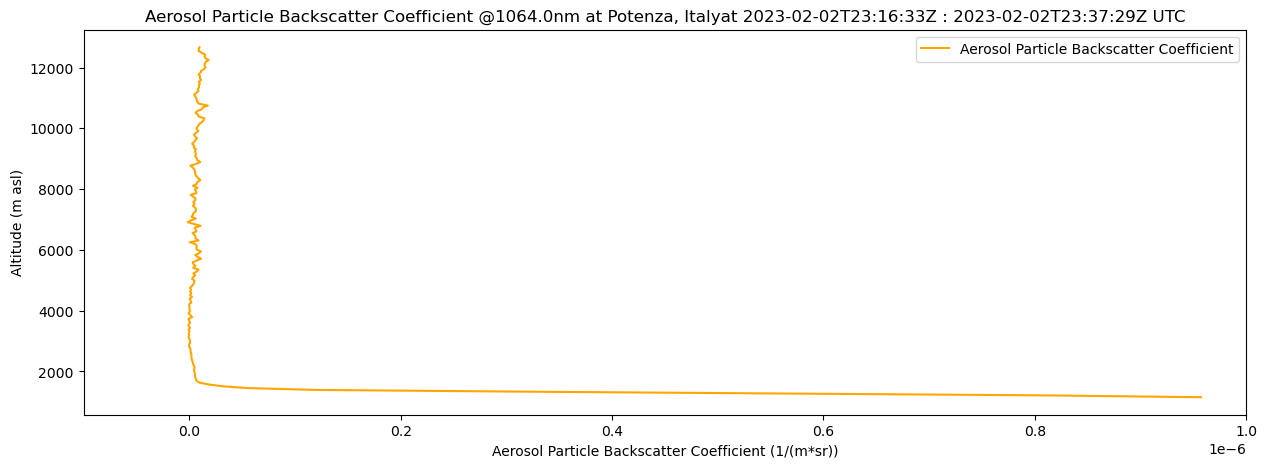

In [30]:
# Choosing the variables we want to plot from "Data variables"
variabletoplot_ds = ds.backscatter
variabletoplot_ds = variabletoplot_ds.fillna(0)
altitude_ds = ds.altitude

# Attributes
wavelength = ds.wavelength[0].values
location = ds.location
measurement_start = ds.measurement_start_datetime
measurement_stop = ds.measurement_stop_datetime

# Plotting the data
plt.figure(figsize=(15, 5))
plt.plot(variabletoplot_ds[0][0][:], altitude_ds[:], label='Aerosol Particle Backscatter Coefficient', color="orange")

plt.legend()
plt.ylabel('Altitude (m asl)')
plt.xlabel('Aerosol Particle Backscatter Coefficient (1/(m*sr))')
plt.xlim(-0.0000001,0.000001)
plt.title('Aerosol Particle Backscatter Coefficient @' + str(wavelength) +'nm at ' + location + ' at ' + measurement_start + ' : ' + measurement_stop + ' UTC')
plt.show()